<a href="https://colab.research.google.com/github/LSHummel/1CCPG_SERS_FIAP_2026/blob/main/AULA_06_ML_SERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercício

Treinar um modelo preditivo de clasificação da estabilidade de uma rede elétrica.

Fonte:

## Preparação do ambiente

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
# Algoritmo do sklearn para classificação
from sklearn.linear_model import LogisticRegression # probrabilidade
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression

# Separação dos dados de treino e teste
from sklearn.model_selection import train_test_split
# X_trains, X_test, y_train, y_test

# Métricas para classificação
from sklearn.metrics import accuracy_score # acurácia
from sklearn.metrics import confusion_matrix # identificação de onde o modelo errou
from sklearn.metrics import classification_report # resumo de métrica

## Carregar os dados e gerar um DataFrame

In [2]:
dados = pd.read_csv('https://raw.githubusercontent.com/LSHummel/FIAP_SERS/refs/heads/main/Data_for_UCI_named.csv')

In [3]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


## Análise Exploratória

In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [5]:
# Somente  estatísticas de atributos categóricos
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [6]:
# Somente estatísticas de atributos numéricos
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [7]:
# Checando a quantidade de classes da coluna alvo (stabf)
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [8]:
# Checando a quantidade de valortes de cada classe da coluna alvo (stabf)
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


## Separação de dados:

Entrada (features) ----> X

Saída (target) ----> y

In [9]:
# Features
X = dados.drop(['stab', 'stabf'], axis=1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [10]:
# Target
y = dados['stabf']
y.head()

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable


In [11]:
# Renomeando as classes da coluna alvo (target)

y = y.map({'stable': 'estavel', 'unstable': 'instável'})
y.head()

,stabf
0,instável
1,estavel
2,instável
3,instável
4,instável


## Separação de dados de treino e teste

In [12]:
# X_train, X_test, y_train, y_test
# Amostra aleatória para treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)
# Amostra estratificada (balanceamento de classes)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=17)

In [13]:
X.shape

(10000, 12)

In [14]:
X_train.shape

(8000, 12)

In [15]:
X_test.shape

(2000, 12)

In [16]:
y_train.shape

(8000,)

In [17]:
y_test.shape

(2000,)

In [18]:
y_train.value_counts()

,count
stabf,
instável,5105
estavel,2895


## Treinamento e geração das previsões do modelo

In [19]:
# instanciando o modelo
modelo_LR = LogisticRegression()

In [20]:
# Treinando o modelo
modelo_LR.fit(X_train, y_train)

LogisticRegression()

In [21]:
# Gerando as previsões
y_predict = modelo_LR.predict(X_test)
y_predict

array(['instável', 'instável', 'instável', ..., 'estavel', 'instável',
       'instável'], dtype=object)

## Avalição do modelo

In [22]:
# Acurácia
acuracia = 100 * accuracy_score(y_test, y_predict)
print(f'A acurácia do modelo baseado em Regressão Logistica é: {acuracia:.2f}')

A acurácia do modelo baseado em Regressão Logistica é: 82.45


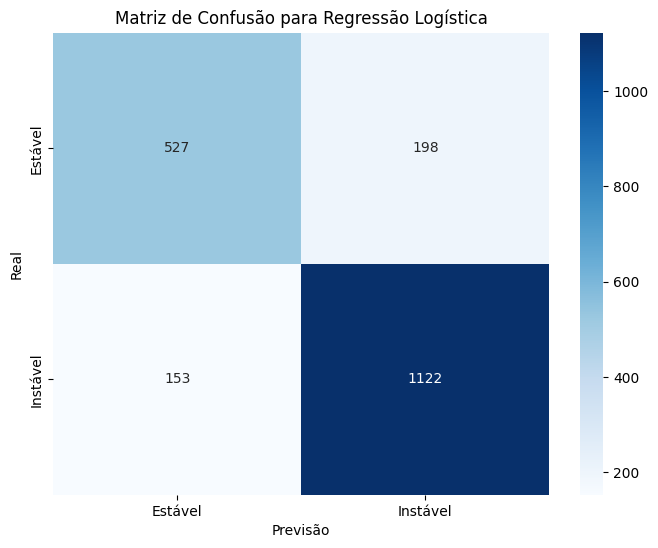

In [23]:
matriz_confusao = confusion_matrix(y_test, y_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Estável', 'Instável'], yticklabels=['Estável', 'Instável'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão para Regressão Logística')
plt.show()

In [24]:
# Classification Report
report = classification_report(y_test, y_predict)
print(report)

              precision    recall  f1-score   support

     estavel       0.78      0.73      0.75       725
    instável       0.85      0.88      0.86      1275

    accuracy                           0.82      2000
   macro avg       0.81      0.80      0.81      2000
weighted avg       0.82      0.82      0.82      2000



# Exercicio 2

Criar um repositório no GitHub para o projeto do CP2

Conectar o seu notebook Python do exemplo de classificação
(aula anterior)ao seu repositório
(Arquivo ----> Salvar cópia no GitHub)

Upload do arquivo Data_for_UCI_named.csv para o repositório
CLASSIFICAÇÃO ----> PREVISÃO DE CLASSES
REGRESSÃO ----> PREVISÃO DE NÚMEROS

Novo exercício:
Treinar um modelo de regressão linear para prever os valores
da coluna 'stab'.
sklearn ----> LinearRegression
Para essa tarefa é necessário que o grupo encontre as features
que possuam maior correlação linear com a variável alvo 'stab'.
Dica: crie uma matriz de correlação usando heatmap com
o matplotlib e/ou seaborn

y ---> target ---> dados da coluna 'stab'
X ---> features ------> dataframe com as features com maior
correlação linear com a coluna 'stab'

Métricas:
Coeficiente de determinação R2
MAE
MSE

Gerar os gráficos de correlação entre 'stab' e as variáveis
de entrada.
Gerar o gráfico Real x Previsto

In [30]:
# Instanciando o modelo_LR com base na classe LinearRegression
modelo_LR = LinearRegression()

In [ ]:
# Features (dataframe X) ----> 3 atributos que tenham maior correlação linear
# coluna alvo (target) ---> 'stab'

In [31]:
# Target
y = dados['stab']
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


Para essa tarefa é necessário que o grupo encontre as features que possuam maior correlação linear com a variável alvo 'stab'. Dica: crie uma matriz de correlação usando heatmap com o matplotlib e/ou seaborn a partir de todos os atributos do dataframe 'dados'

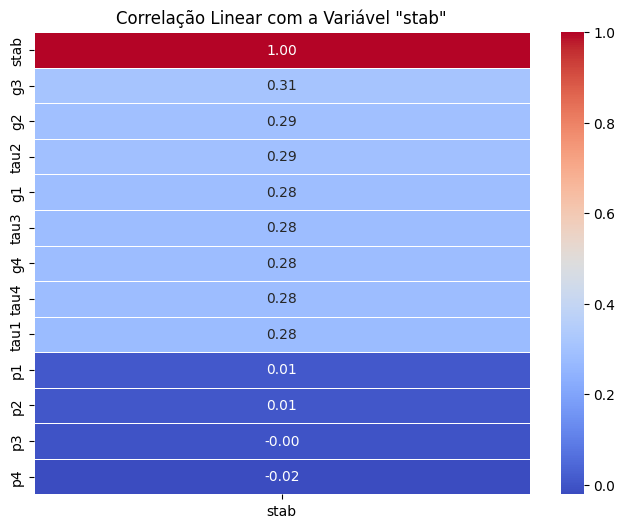

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the entire dataset
correlation_matrix = dados.corr(numeric_only=True)

# Extract correlations with the 'stab' variable and sort them
stab_correlations = correlation_matrix[['stab']].sort_values(by='stab', ascending=False)

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(stab_correlations, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlação Linear com a Variável "stab"')
plt.show()

Gere os graficos de dispersão das 3 variaveis de maior disperção em x e a variavel 'stab' em y. Plote também a reta de regressão. Apresente os graficos lado a lado em uma imagem. Fundo preto

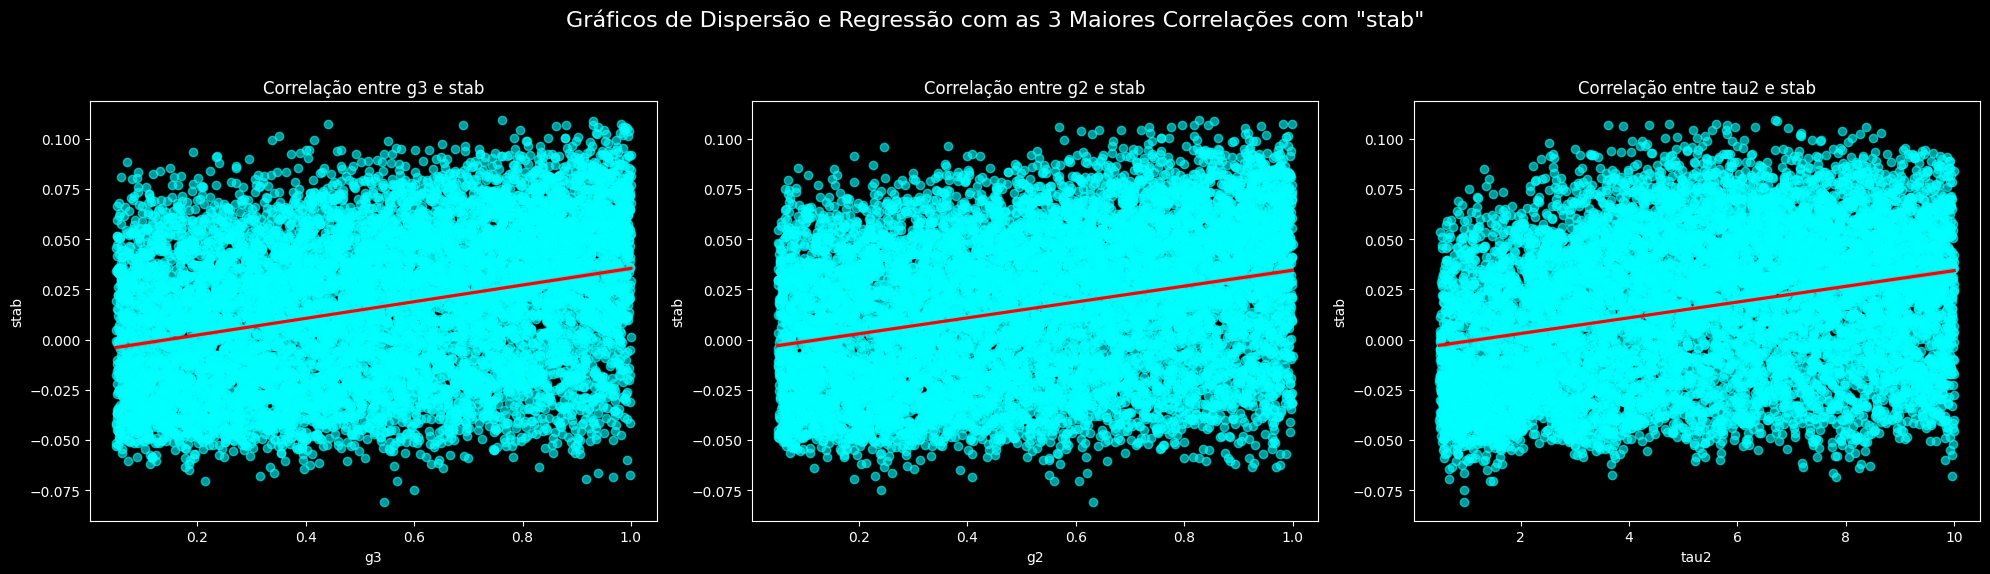

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the top 3 features most correlated with 'stab' (excluding 'stab' itself)
top_3_features = stab_correlations.index[1:4].tolist()

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='black')
fig.suptitle('Gráficos de Dispersão e Regressão com as 3 Maiores Correlações com "stab"', color='white', fontsize=16)

for i, feature in enumerate(top_3_features):
    ax = axes[i]
    ax.set_facecolor('black')
    sns.regplot(x=dados[feature], y=dados['stab'], ax=ax, scatter_kws={'color': 'cyan', 'alpha': 0.6}, line_kws={'color': 'red'})
    ax.set_title(f'Correlação entre {feature} e stab', color='white')
    ax.set_xlabel(feature, color='white')
    ax.set_ylabel('stab', color='white')
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.spines['top'].set_color('white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [39]:
# Dados de entrada do modelo (X):
X = dados[['tau2', 'g2', 'g3']]
X.head()

,tau2,g2,g3
0,3.079885,0.859578,0.887445
1,4.902524,0.862414,0.562139
2,8.848428,0.766689,0.839444
3,7.669600,0.976744,0.929381
4,7.608772,0.455450,0.656947


In [40]:
# Separando dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=17)

In [41]:
# Treinamento do modelo de regressão linear
modelo_LR.fit(X_train, y_train)

LinearRegression()

In [44]:
# Gerando previsões
y_predict = modelo_LR.predict(X_test)
y_predict[:50]

array([ 0.02836254,  0.01491935,  0.01758781,  0.00557947, -0.00152692,
        0.00370801,  0.00607375,  0.02169718,  0.0055979 ,  0.01720782,
       -0.00894882,  0.03726513, -0.02117957,  0.0052061 ,  0.03989881,
        0.05255102,  0.02100049,  0.0360181 ,  0.01824608,  0.03023555,
        0.00952129, -0.02415203,  0.02188019,  0.00713168,  0.02055473,
        0.0065953 ,  0.00856773,  0.03413339,  0.01360304, -0.00475366,
        0.01860118,  0.00460138, -0.02415915,  0.01177945,  0.0313005 ,
       -0.02623412,  0.03292247,  0.01925688,  0.0412256 ,  0.01290649,
        0.03636565,  0.02181991, -0.01101281,  0.03839857, -0.00045866,
        0.00047298, -0.01898246,  0.05211772, -0.0036266 ,  0.03484327])

In [45]:
# Métricas:
# Coeficiente de determinação R2
# MAE: erro médio absoluto
# MSE: eero médio quadrático

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
# Melhor modelode regressão
# R2 precisa ser alto
# Os erros precisam ser baixos

In [46]:
print(f"Coeficiente de determinação (R2): {r2_score(y_test, y_predict):.2f}")
print(f"Erro médio absoluto (MAE): {mean_absolute_error(y_test, y_predict):.2f}")
print(f"Erro médio quadrático (MSE): {mean_squared_error(y_test, y_predict):.2f}")

Coeficiente de determinação (R2): 0.27
Erro médio absoluto (MAE): 0.03
Erro médio quadrático (MSE): 0.00
